# Startup Research

## Introduction

### Main Goals of the Project
- Data preprocessing and development of structure
- Analysis of factors influencing successful deals

### Project Tasks
- Get familiar with the data
- Verify data correctness
- Perform exploratory data analysis

### Project Contents
1. Getting to know the data: loading and initial preprocessing
2. Data preprocessing and preliminary exploration
3. Exploratory analysis of merged tables
4. Final conclusions and recommendations
---

## 1. Getting to Know the Data: Loading and Initial Preprocessing

### 1.1 Retrieving General Information and Fixing Column Names

In [8]:
# Install the phik library
!pip install phik -U

In [187]:
# Import the library for data analysis
import pandas as pd

# Import libraries for visualizations
import matplotlib.pyplot as plt
import seaborn as sns

# Load the library for calculating the phi_k correlation coefficient
from phik import phik_matrix

import re

In [10]:
url = 'https://code.s3.yandex.net/datasets/'

# Load data into DataFrames
acquisition_df = pd.read_csv(f'{url}acquisition.csv')

comp_rounds = pd.read_csv(f'{url}company_and_rounds.csv')

education_df = pd.read_csv(f'{url}education.csv')

people_df = pd.read_csv(f'{url}people.csv')

degrees_df = pd.read_csv(f'{url}degrees.csv')

Get familiar with the dataset. Display the first five rows of the DataFrames using the `head()` function and get general information using the `info()` function.

In [12]:
# Display the first rows of the DataFrame
acquisition_df.head()

,id,acquiring_company_id,acquired_company_id,term_code,price_amount,acquired_at
0,1,11,10,NaN,20000000,2007-05-30
1,7,59,72,cash,60000000,2007-07-01
2,8,24,132,cash,280000000,2007-05-01
3,9,59,155,cash,100000000,2007-06-01
4,10,212,215,cash,25000000,2007-07-01


In [13]:
# Display information about the dataframe
acquisition_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9407 entries, 0 to 9406
Data columns (total 6 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   id                    9407 non-null   int64 
 1   acquiring_company_id  9407 non-null   int64 
 2   acquired_company_id   9407 non-null   int64 
 3   term_code             1831 non-null   object
 4   price_amount          9407 non-null   int64 
 5   acquired_at           9378 non-null   object
dtypes: int64(4), object(2)
memory usage: 441.1+ KB


DataFrame `acquisition_df` contains 6 columns and 9407 rows. This dataset provides information about companies and funding rounds. After the initial look at the data, we can make the following observations:

- Column names are already convenient for use
  
- The DataFrame contains 4 columns with the data type `int64` (the first three columns contain identifiers: `id`, `acquiring_company_id`, `acquired_company_id`, and one more column with deal amount: `price_amount`)

- Another 2 columns have the data type `object` (`term_code` – payment terms, and `acquired_at` – deal date)

- Missing values are present in two columns: `term_code` and `acquired_at`

- Values in the columns correspond to their names, except for the `acquired_at` column which contains date information that will later need to be converted to the `datetime64` type

In [15]:
# Display the first rows of the dataframe
comp_rounds.head()

,company ID,name,category code,status,founded at,closed at,domain,network username,country code,investment rounds,...,milestones,funding round id,company id,funded at,funding round type,raised amount,pre money valuation,participants,is first round,is last round
0,1.0,Wetpaint,web,operating,2005-10-17,NaN,wetpaint-inc.com,BachelrWetpaint,USA,0.0,...,5.0,888.0,1.0,2005-10-01,series-a,5250000.0,0.0,2.0,0.0,1.0
1,1.0,Wetpaint,web,operating,2005-10-17,NaN,wetpaint-inc.com,BachelrWetpaint,USA,0.0,...,5.0,889.0,1.0,2007-01-01,series-b,9500000.0,0.0,3.0,0.0,0.0
2,1.0,Wetpaint,web,operating,2005-10-17,NaN,wetpaint-inc.com,BachelrWetpaint,USA,0.0,...,5.0,2312.0,1.0,2008-05-19,series-c+,25000000.0,0.0,4.0,1.0,0.0
3,10.0,Flektor,games_video,acquired,NaN,NaN,flektor.com,NaN,USA,0.0,...,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,100.0,There,games_video,acquired,NaN,NaN,there.com,NaN,USA,0.0,...,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [16]:
# Display information about the dataframe
comp_rounds.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 217774 entries, 0 to 217773
Data columns (total 22 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   company  ID            217472 non-null  float64
 1   name                   217471 non-null  object 
 2   category  code         143886 non-null  object 
 3   status                 217472 non-null  object 
 4   founded  at            109956 non-null  object 
 5   closed  at             3449 non-null    object 
 6   domain                 147159 non-null  object 
 7   network  username      95534 non-null   object 
 8   country  code          108607 non-null  object 
 9   investment  rounds     217472 non-null  float64
 10  funding  rounds        217472 non-null  float64
 11  funding  total         217472 non-null  float64
 12  milestones             217472 non-null  float64
 13  funding  round  id     52928 non-null   float64
 14  company  id            52928 non-nul

The `comp_rounds` dataframe has 22 columns and contains 217774 rows. This dataset provides information about companies and funding rounds. After a first look at the data, we can make the following observations:

- Column names will need to be converted to lowercase and follow the snake_case naming convention
- The dataframe contains the following data types: `float64` and `object`
- Missing values are present in every column, which should be taken into account during further analysis
- Values in the columns correspond to their names, but there are some concerns regarding several columns — the columns `founded at` and `funded at` contain date information that will need to be converted to the `datetime64` data type. Also, identifier columns have values stored as `float64`, likely due to the presence of missing values

In [18]:
# Convert column names to snake_case style
comp_rounds = comp_rounds.rename(columns={
    'company  ID': 'company_id_1',
    'company  id': 'company_id_2'
})

In [20]:
# Convert column names to lowercase snake_case style
comp_rounds.columns = (comp_rounds.columns.str.lower().str.replace(r'\s+', '_', regex=True)  # Заменяем любые пробелы одним подчеркиванием
)

In [21]:
# Check our changes
comp_rounds.columns

Index(['company_id_1', 'name', 'category_code', 'status', 'founded_at',
       'closed_at', 'domain', 'network_username', 'country_code',
       'investment_rounds', 'funding_rounds', 'funding_total', 'milestones',
       'funding_round_id', 'company_id_2', 'funded_at', 'funding_round_type',
       'raised_amount', 'pre_money_valuation', 'participants',
       'is_first_round', 'is_last_round'],
      dtype='object')

In [22]:
# Display the first rows of the dataframe
education_df.head()

,id,person_id,instituition,graduated_at
0,1,6117,NaN,NaN
1,2,6136,"Washington University, St. Louis",1990-01-01
2,3,6136,Boston University,1992-01-01
3,4,6005,University of Greenwich,2006-01-01
4,5,5832,Rice University,NaN


In [23]:
# Display information about the dataframe
education_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 109610 entries, 0 to 109609
Data columns (total 4 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   id            109610 non-null  int64 
 1   person_id     109610 non-null  int64 
 2   instituition  109555 non-null  object
 3   graduated_at  58054 non-null   object
dtypes: int64(2), object(2)
memory usage: 3.3+ MB


The `education_df` dataframe has 4 columns and contains 109610 rows. This dataset provides information about employees' education. After a first look at the data, we can make the following observations:

- Column names are already convenient for use
- The dataframe contains the following data types: `object` (`institution` — name of the educational institution, and `graduated_at` — graduation date), and `int64` (identifier values — `id` and `person_id`)
- Missing values are present in two columns — `institution` and `graduated_at`
- Values in the columns correspond to their names, except for the `graduated_at` column, which contains date information that will need to be converted to the `datetime64` data type

In [25]:
# Display the first rows of the dataframe
people_df.head()

,id,first_name,last_name,company_id,network_username
0,10,Mark,Zuckerberg,5.0,NaN
1,100,Peter,Lester,27.0,NaN
2,1000,Dr. Steven,E. Saunders,292.0,NaN
3,10000,Neil,Capel,2526.0,NaN
4,100000,Sue,Pilsch,NaN,NaN


In [26]:
# Display information about the dataframe
people_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 226709 entries, 0 to 226708
Data columns (total 5 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   id                226709 non-null  int64  
 1   first_name        226700 non-null  object 
 2   last_name         226705 non-null  object 
 3   company_id        34615 non-null   float64
 4   network_username  38867 non-null   object 
dtypes: float64(1), int64(1), object(3)
memory usage: 8.6+ MB


The `people_df` dataframe has 5 columns and contains 226709 rows. This dataset provides information about employees. After a first look at the data, we can make the following observations:

- Column names are already convenient for use
- The dataframe contains the following data types: `float64`, `object`, and `int64`
- Missing values are present in 4 columns — `first_name`, `last_name`, `company_id`, and `network_username`
- Values in the columns correspond to their names, except for the `company_id` column, which has the `float64` data type due to the presence of missing values

In [28]:
# Display the first rows of the dataframe
degrees_df.head()

,id,object_id,degree_type,subject
0,1,p:6117,MBA,NaN
1,2,p:6136,BA,"English, French"
2,3,p:6136,MS,Mass Communication
3,4,p:6005,MS,Internet Technology
4,5,p:5832,BCS,"Computer Science, Psychology"


In [29]:
# Display information about the dataframe
degrees_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 109610 entries, 0 to 109609
Data columns (total 4 columns):
 #   Column       Non-Null Count   Dtype 
---  ------       --------------   ----- 
 0   id           109610 non-null  int64 
 1   object_id    109610 non-null  object
 2   degree_type  98389 non-null   object
 3   subject      81298 non-null   object
dtypes: int64(1), object(3)
memory usage: 3.3+ MB


The `degrees_df` dataframe has 4 columns and contains 109610 rows. This dataset provides information about employees' education types. After a first look at the data, we can make the following observations:

- Column names are already convenient for use
- The dataframe contains the following data types: `object` and `int64`
- Missing values are present in 2 columns — `degree_type` and `subject`
- Values in the columns correspond to their names

In [31]:
# Add 2 additional tables
fund_df = pd.read_csv('https://code.s3.yandex.net/datasets/fund.csv')

investment_df = pd.read_csv('https://code.s3.yandex.net/datasets/investment.csv')

In [32]:
# Display the first rows of the dataframe
fund_df.head()

,id,name,founded_at,domain,network_username,country_code,investment_rounds,invested_companies,milestones
0,13131,NaN,NaN,NaN,NaN,NaN,0,0,0
1,1,Greylock Partners,1965-01-01,greylock.com,greylockvc,USA,307,196,0
2,10,Mission Ventures,1996-01-01,missionventures.com,NaN,USA,58,33,0
3,100,"Kapor Enterprises, Inc.",NaN,kei.com,NaN,USA,2,1,0
4,1000,Speed Ventures,NaN,NaN,NaN,NaN,0,0,1


In [33]:
# Display information about the dataframe
fund_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11652 entries, 0 to 11651
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   id                  11652 non-null  int64 
 1   name                11649 non-null  object
 2   founded_at          4605 non-null   object
 3   domain              7362 non-null   object
 4   network_username    2149 non-null   object
 5   country_code        7053 non-null   object
 6   investment_rounds   11652 non-null  int64 
 7   invested_companies  11652 non-null  int64 
 8   milestones          11652 non-null  int64 
dtypes: int64(4), object(5)
memory usage: 819.4+ KB


In [34]:
# Display the first rows of the dataframe
investment_df.head()

,id,funding_round_id,company_id,fund_id
0,1,1,4,1
1,2,1,4,2
2,3,3,5,4
3,4,4,5,1
4,5,4,5,5


In [35]:
# Display information about the dataframe
investment_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 61403 entries, 0 to 61402
Data columns (total 4 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   id                61403 non-null  int64
 1   funding_round_id  61403 non-null  int64
 2   company_id        61403 non-null  int64
 3   fund_id           61403 non-null  int64
dtypes: int64(4)
memory usage: 1.9 MB



### 1.2 Changing Data Types and Analyzing Missing Values

We will process the dataframes that store date and time values and change their data types accordingly

In [38]:
# Convert data type to datetime64[ns]
acquisition_df['acquired_at'] = acquisition_df['acquired_at'].astype('datetime64[ns]')

In the `comp_rounds` dataframe, the date columns contain a large number of missing values.

In the `founded_at` column, which contains information about founding dates, missing values make up 49.5% of all data. However, we can assume that not every company required funding, especially at early stages. Therefore, these missing values can be considered natural and do not necessarily indicate errors in the data.

Similar patterns are observed in the other two columns:

- `closed_at` (meaning the company has not yet closed)
- `funded_at` (meaning the company did not require funding)

These can all be classified as MNAR (Missing Not At Random)

In [40]:
# Convert data type to datetime64[ns]
comp_rounds['founded_at'] = pd.to_datetime(comp_rounds['founded_at'], errors='coerce')
comp_rounds['closed_at'] = pd.to_datetime(comp_rounds['closed_at'], errors='coerce')
comp_rounds['funded_at'] = pd.to_datetime(comp_rounds['funded_at'], errors='coerce')

In [41]:
# Convert data type to datetime64[ns]
education_df['graduated_at'] = pd.to_datetime(education_df['graduated_at'], errors='coerce')

In [42]:
fund_df['founded_at'] = pd.to_datetime(fund_df['founded_at'], errors='coerce')

For further analysis, we will create a new column containing only the year from each date in the `comp_rounds` dataframe for convenience.

In [44]:
# Extract the year
comp_rounds['year_fundet'] = comp_rounds['funded_at'].map(lambda x: x.year)

comp_rounds = comp_rounds.dropna(subset=['company_id_1'])

At this stage, we need the year column from the funding date to proceed with further analysis — specifically, "Funding Rounds by Year". It will be convenient to create it in advance and use it for future analysis and visualizations. This level of detail is sufficient for solving the tasks of the project.

---
## 2. Data Preprocessing, Preliminary Exploration

### 2.1 Funding Rounds by Year

In [48]:
# Create a summary table
year_funding = comp_rounds.groupby('year_fundet').agg(
    typical_amount = ('raised_amount', 'median'),
    total_round = ('raised_amount', 'count')
).reset_index()

# Keep only years with more than 50 funding rounds
year_funding_sort = year_funding[year_funding['total_round'] > 50]

year_funding_sort.sort_values('year_fundet')

,year_fundet,typical_amount,total_round
15,1999.0,2000000.0,76
16,2000.0,4200000.0,125
17,2001.0,3000000.0,95
18,2002.0,4200000.0,115
19,2003.0,3000000.0,154
20,2004.0,5000000.0,286
21,2005.0,5500000.0,1624
22,2006.0,5000000.0,2409
23,2007.0,4000000.0,3220
24,2008.0,3152000.0,3735


Text(0, 0.5, 'Typical Funding Amount')

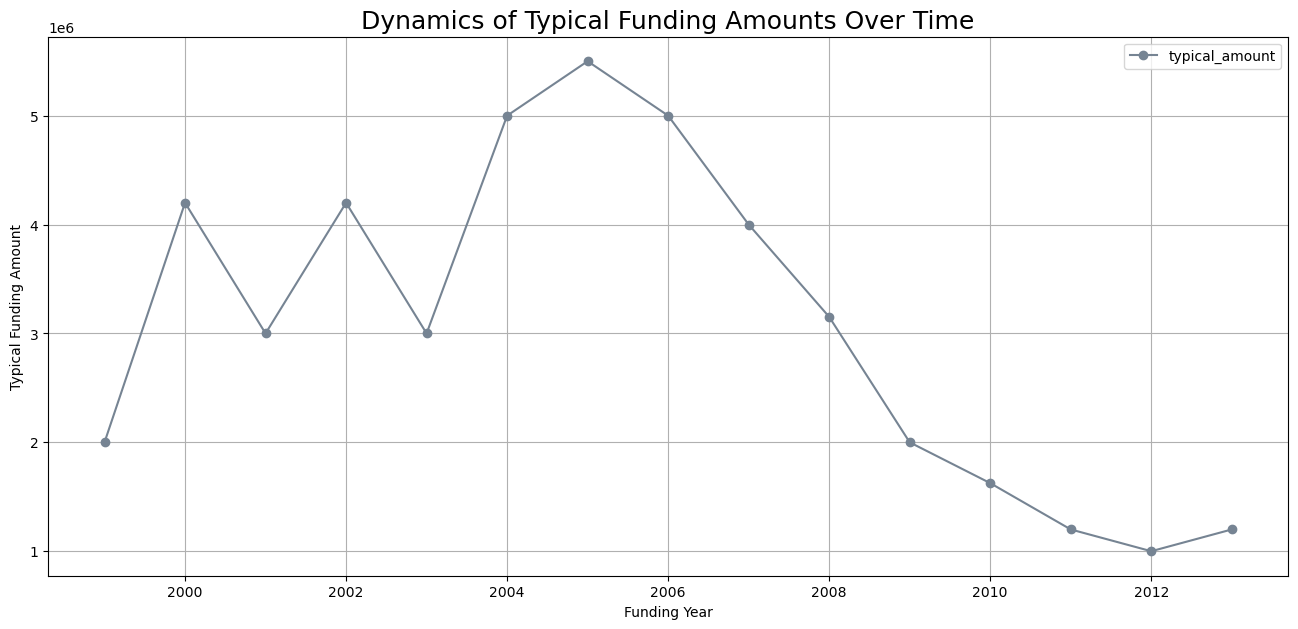

In [49]:
year_funding = year_funding_sort[year_funding_sort['year_fundet'] > 1990]


year_funding_sort.plot(kind='line',
                  x='year_fundet',
                  y='typical_amount',
                  marker='o',
                  color='#768493',
                  figsize=(16, 7))

plt.grid()
plt.title('Dynamics of Typical Funding Amounts Over Time', fontsize=18)
plt.xlabel('Funding Year')
plt.ylabel('Typical Funding Amount')

Based on the data obtained, we can answer the main questions:

1. The highest typical funding amount was in 2005, with a median value of 5000000.0. After that, values decreased each year.
2. In 2013, the typical funding amount per round was at a median level of 650000, compared to 350000 in 2012 — significantly higher than the previous year. In 2013, there were 25 funding rounds, while in 2012 there were already 177.

---
### 2.2 People and Their Education

In [52]:
# Combine data to facilitate analysis
edu_people_df = pd.merge(education_df, people_df, left_on='person_id', right_on='id', how='right', suffixes=('_educations', '_people'))

# Check the column
edu_people_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 267694 entries, 0 to 267693
Data columns (total 9 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   id_educations     109056 non-null  float64       
 1   person_id         109056 non-null  float64       
 2   instituition      109002 non-null  object        
 3   graduated_at      57691 non-null   datetime64[ns]
 4   id_people         267694 non-null  int64         
 5   first_name        267685 non-null  object        
 6   last_name         267690 non-null  object        
 7   company_id        44789 non-null   float64       
 8   network_username  50775 non-null   object        
dtypes: datetime64[ns](1), float64(3), int64(1), object(4)
memory usage: 18.4+ MB


In [53]:
# Verify Employees Education Status
uneducated = edu_people_df['instituition'].isna().sum()
have_education = edu_people_df['instituition'].notna().sum()

print(f"Number of employees with education: {have_education}")
print(f"Number of employees without education: {uneducated}")

Number of employees with education: 109002
Number of employees without education: 158692


In [54]:
# Added import of the warnings library
import warnings
# Added warning filter setup
warnings.filterwarnings("ignore")


# Count the number of employees in each company
edu_people_df['company_size'] = edu_people_df.groupby('company_id').size()

edu_people_df['people_categorization'] = pd.cut(
    edu_people_df['company_size'],
    bins=[0, 20, 50, 200],
    labels=['small', 'medium', 'large'],
    right=False
)

# Add a new category 'no_category' to the 'people_categorization' column
edu_people_df['people_categorization'] = edu_people_df['people_categorization'].cat.add_categories(['uncategorized'])
# Replace NaN values with 'no_category'
edu_people_df['people_categorization'].fillna('uncategorized', inplace=True)

# Check our groups
display(edu_people_df)

,id_educations,person_id,instituition,graduated_at,id_people,first_name,last_name,company_id,network_username,company_size,people_categorization
0,2415.0,10.0,Harvard University,NaT,10,Mark,Zuckerberg,5.0,NaN,NaN,uncategorized
1,NaN,NaN,NaN,NaT,100,Peter,Lester,27.0,NaN,3.0,small
2,NaN,NaN,NaN,NaT,1000,Dr. Steven,E. Saunders,292.0,NaN,1.0,small
3,NaN,NaN,NaN,NaT,10000,Neil,Capel,2526.0,NaN,5.0,small
4,NaN,NaN,NaN,NaT,100000,Sue,Pilsch,NaN,NaN,18.0,small
...,...,...,...,...,...,...,...,...,...,...,...
267689,NaN,NaN,NaN,NaT,99999,Ramon,Peypoch,NaN,NaN,NaN,uncategorized
267690,25958.0,174088.0,Sydney University Medical School,1982-01-01,174088,Dr. Ray,Woods,188200.0,network,NaN,uncategorized
267691,18871.0,118386.0,ESCS,2004-01-01,118386,Ricardo,Durand,143419.0,itechsocialnet,NaN,uncategorized
267692,NaN,NaN,NaN,NaT,175827,mahesh,kumar,NaN,socialnethubs,NaN,uncategorized


In [55]:
# Count the number of unique people in each group
display(edu_people_df.groupby('people_categorization')['person_id'].nunique())

people_categorization
small             7764
medium              15
large                4
uncategorized    64911
Name: person_id, dtype: int64

Justification for group selection:

1. Small group (1–20) — includes small companies and startups
2. Medium group (21–50) — represents growing companies
3. Large group (51–200) — includes corporations and large market players

In [57]:
# Calculate the share of employees without education information by group
education_stats = edu_people_df.groupby('people_categorization')['instituition'].apply(lambda x: x.isna().mean()*100).reset_index(name='undereducation rate')

display(education_stats)

,people_categorization,undereducation rate
0,small,62.334362
1,medium,62.500000
2,large,66.666667
3,uncategorized,59.006295


According to the data, about 62% of employees in small companies have no education information recorded, 62% in medium-sized companies, and 66% in large companies.

For this task, we could have also joined the `degrees.csv` table. However, in our case, it contains limited information useful for this particular analysis, as it only provides details about the type of education an employee has. If needed, we could join it using the column:
`object_id` — the employee's identifier.

---
### 2.3 To Merge or Not to Merge

- Determine whether the column `network_username` — which appears in multiple datasets — is suitable for joining data. We need to understand whether the information in columns with this name duplicates across different datasets, and if so, how often.
- Evaluate whether the columns named `network_username` can be used to merge datasets.

In [62]:
print(f'Number of missing values in the network_username column in the comp_rounds dataframe: {comp_rounds["network_username"].isna().sum()}')
print(f'Percentage of missing values in the network_username column in the comp_rounds dataframe: {round(comp_rounds["network_username"].isna().mean() * 100, 2)}')
print(f'Number of duplicates in the network_username column in the comp_rounds dataframe: {comp_rounds.duplicated(subset="network_username").sum() - comp_rounds["network_username"].isna().sum()}')
print()
print(f'Number of missing values in the network_username column in the people_df dataframe: {people_df["network_username"].isna().sum()}')
print(f'Percentage of missing values in the network_username column in the people_df dataframe: {round(people_df["network_username"].isna().mean() * 100, 2)}')
print(f'Number of duplicates in the network_username column in the people_df dataframe: {people_df.duplicated(subset="network_username").sum() - people_df["network_username"].isna().sum()}')

Number of missing values in the network_username column in the comp_rounds dataframe: 121938
Percentage of missing values in the network_username column in the comp_rounds dataframe: 56.07
Number of duplicates in the network_username column in the comp_rounds dataframe: 15962

Number of missing values in the network_username column in the people_df dataframe: 187842
Percentage of missing values in the network_username column in the people_df dataframe: 82.86
Number of duplicates in the network_username column in the people_df dataframe: 445


The column `network_username` is present in two dataframes — `comp_rounds` and `people_df`.

DataFrame comp_rounds:

- Missing values: 122240 (56.13%) — which means that half of the entries are missing
- Duplicates: 15962 — indicates that there are repeated values in this column

DataFrame people_df:
- Missing values: 187842 (82.86%)
- Duplicates: 445
  
The data in `comp_rounds` looks more complete and higher quality compared to `people_df`, as it has fewer missing values and fewer duplicates.

We can join the dataframes by `network_username`, but for that we will need to remove missing values from both columns — since we cannot restore or replace them (this is company username in a network, and we can't guess or impute it). Unless we manually search for and fill in the missing usernames, which would be a very time-consuming process. We will also need to remove duplicates, as they will interfere with the join.

Additionally, in the `people_df` dataframe, information about only 38,867 companies is present, while in the `comp_rounds` dataframe — 1098 companies .

---
### 2.4 Problematic Dataset and the Cause of Missing Values

We'll start by eliminating the duplication of the `company_id` column.

The dataset previously contained two seemingly identical columns:

- `company ID` — company identifier (later renamed to `company_ID`)
- and exactly the same `company id` — company identifier (also later renamed to `company_id`)

We can assume that these were originally two different dataframes with different numbers of rows. After merging them into one, a decision was made to keep a single combined dataframe — but the duplicate column was not removed.

In [66]:
comp_rounds.info()

<class 'pandas.core.frame.DataFrame'>
Index: 217472 entries, 0 to 217471
Data columns (total 23 columns):
 #   Column               Non-Null Count   Dtype         
---  ------               --------------   -----         
 0   company_id_1         217472 non-null  float64       
 1   name                 217471 non-null  object        
 2   category_code        143886 non-null  object        
 3   status               217472 non-null  object        
 4   founded_at           109956 non-null  datetime64[ns]
 5   closed_at            3449 non-null    datetime64[ns]
 6   domain               147159 non-null  object        
 7   network_username     95534 non-null   object        
 8   country_code         108607 non-null  object        
 9   investment_rounds    217472 non-null  float64       
 10  funding_rounds       217472 non-null  float64       
 11  funding_total        217472 non-null  float64       
 12  milestones           217472 non-null  float64       
 13  funding_round_id   

Next, we will deal with missing values. Let's look at the number of missing values in this column:

In [68]:
# Split the dataset into two parts
columns_df_1 = ['company_id_1', 'name', 'category_code', 'founded_at', 'closed_at', 'domain', 'network_username', 'country_code', 'investment_rounds', 'funding_rounds', 'funding_total', 'status', 'milestones']
columns_df_2 = [col for col in comp_rounds.columns
                if col not in columns_df_1]

# Apply selected columns to the new dataframes
company_data = comp_rounds[columns_df_1]
finance_and_investment = comp_rounds[columns_df_2]

company_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 217472 entries, 0 to 217471
Data columns (total 13 columns):
 #   Column             Non-Null Count   Dtype         
---  ------             --------------   -----         
 0   company_id_1       217472 non-null  float64       
 1   name               217471 non-null  object        
 2   category_code      143886 non-null  object        
 3   founded_at         109956 non-null  datetime64[ns]
 4   closed_at          3449 non-null    datetime64[ns]
 5   domain             147159 non-null  object        
 6   network_username   95534 non-null   object        
 7   country_code       108607 non-null  object        
 8   investment_rounds  217472 non-null  float64       
 9   funding_rounds     217472 non-null  float64       
 10  funding_total      217472 non-null  float64       
 11  status             217472 non-null  object        
 12  milestones         217472 non-null  float64       
dtypes: datetime64[ns](2), float64(5), object(6)
memor

In [69]:
# Change the data type in company_id_1
company_data['company_id_1'] = company_data['company_id_1'].astype('int64')
# Sort by id and reset the index
company_data = company_data.sort_values('company_id_1' ,ascending=True).reset_index(drop=True)

# Check the new dataframes
company_data.head(2)

,company_id_1,name,category_code,founded_at,closed_at,domain,network_username,country_code,investment_rounds,funding_rounds,funding_total,status,milestones
0,1,Wetpaint,web,2005-10-17,NaT,wetpaint-inc.com,BachelrWetpaint,USA,0.0,3.0,39750000.0,operating,5.0
1,1,Wetpaint,web,2005-10-17,NaT,wetpaint-inc.com,BachelrWetpaint,USA,0.0,3.0,39750000.0,operating,5.0


In [70]:
finance_and_investment = finance_and_investment.dropna(subset=['company_id_2'])

# Change the data type in company_id_2
finance_and_investment['company_id_2'] = finance_and_investment['company_id_2'].astype('int64')
finance_and_investment = finance_and_investment.sort_values('company_id_2', ascending=True).reset_index(drop=True)

# Check the new dataframes again
finance_and_investment.head(2)

,funding_round_id,company_id_2,funded_at,funding_round_type,raised_amount,pre_money_valuation,participants,is_first_round,is_last_round,year_fundet
0,888.0,1,2005-10-01,series-a,5250000.0,0.0,2.0,0.0,1.0,2005.0
1,889.0,1,2007-01-01,series-b,9500000.0,0.0,3.0,0.0,0.0,2007.0


In the final output, we have 4 columns with missing values. Let's look at them and immediately discuss the next steps:

- `network_username` (1111 missing values, or 0.50% of total) — company username in a network. We can replace these missing values with 'unknown', since they represent unique identifiers that would be very time-consuming to restore. Replacing them won't negatively impact further analysis — we just need to keep this in mind
- `country_code` (202 missing values, or 0.09%) — company country code. These missing values can also be removed, as their share is very small and won't affect the analysis
- `domain` (21 missing values, or 0.009%) — company’s official website. These missing values can be removed as well, as they won’t interfere with further analysis
- `category_code` (19 missing values, or 0.008%) — category of the company’s activity area. We can leave these missing values as they are, since they don’t interfere with further analysis

In [72]:
# Remove missing values in the columns
company_data = company_data.dropna(subset=['country_code', 'domain'])
finance_and_investment = finance_and_investment.dropna(subset=['funded_at', 'year_fundet'])

# Replace missing values with 'unknown'
company_data['network_username'] = company_data['network_username'].fillna('unknown')

company_data.head(2)

,company_id_1,name,category_code,founded_at,closed_at,domain,network_username,country_code,investment_rounds,funding_rounds,funding_total,status,milestones
0,1,Wetpaint,web,2005-10-17,NaT,wetpaint-inc.com,BachelrWetpaint,USA,0.0,3.0,39750000.0,operating,5.0
1,1,Wetpaint,web,2005-10-17,NaT,wetpaint-inc.com,BachelrWetpaint,USA,0.0,3.0,39750000.0,operating,5.0


This completes the preparation of the column for further analysis:
- We fixed the duplicate column name
- Analyzed missing values and found appropriate solutions

In [74]:
finance_and_investment = finance_and_investment.reindex(columns=['company_id_2', 'funding_round_id', 'funded_at', 'funding_round_type', 'raised_amount', 'pre_money_valuation', 'participants', 'is_first_round', 'is_last_round', 'year_fundet'])

In [75]:
finance_and_investment.head(2)

,company_id_2,funding_round_id,funded_at,funding_round_type,raised_amount,pre_money_valuation,participants,is_first_round,is_last_round,year_fundet
0,1,888.0,2005-10-01,series-a,5250000.0,0.0,2.0,0.0,1.0,2005.0
1,1,889.0,2007-01-01,series-b,9500000.0,0.0,3.0,0.0,0.0,2007.0


---
## 3. Exploratory Analysis of the Merged Tables

### 3.1. Merging Data

In [78]:
# Filter our data based on a condition
company_data_sort = company_data[
(company_data['funding_rounds']>0) |
(company_data['investment_rounds']>0) |
(company_data['status'] == 'acquired')
]

In [79]:
# Check for completeness
company_data_sort.head(2)

,company_id_1,name,category_code,founded_at,closed_at,domain,network_username,country_code,investment_rounds,funding_rounds,funding_total,status,milestones
0,1,Wetpaint,web,2005-10-17,NaT,wetpaint-inc.com,BachelrWetpaint,USA,0.0,3.0,39750000.0,operating,5.0
1,1,Wetpaint,web,2005-10-17,NaT,wetpaint-inc.com,BachelrWetpaint,USA,0.0,3.0,39750000.0,operating,5.0


## 3.2 Outlier Analysis

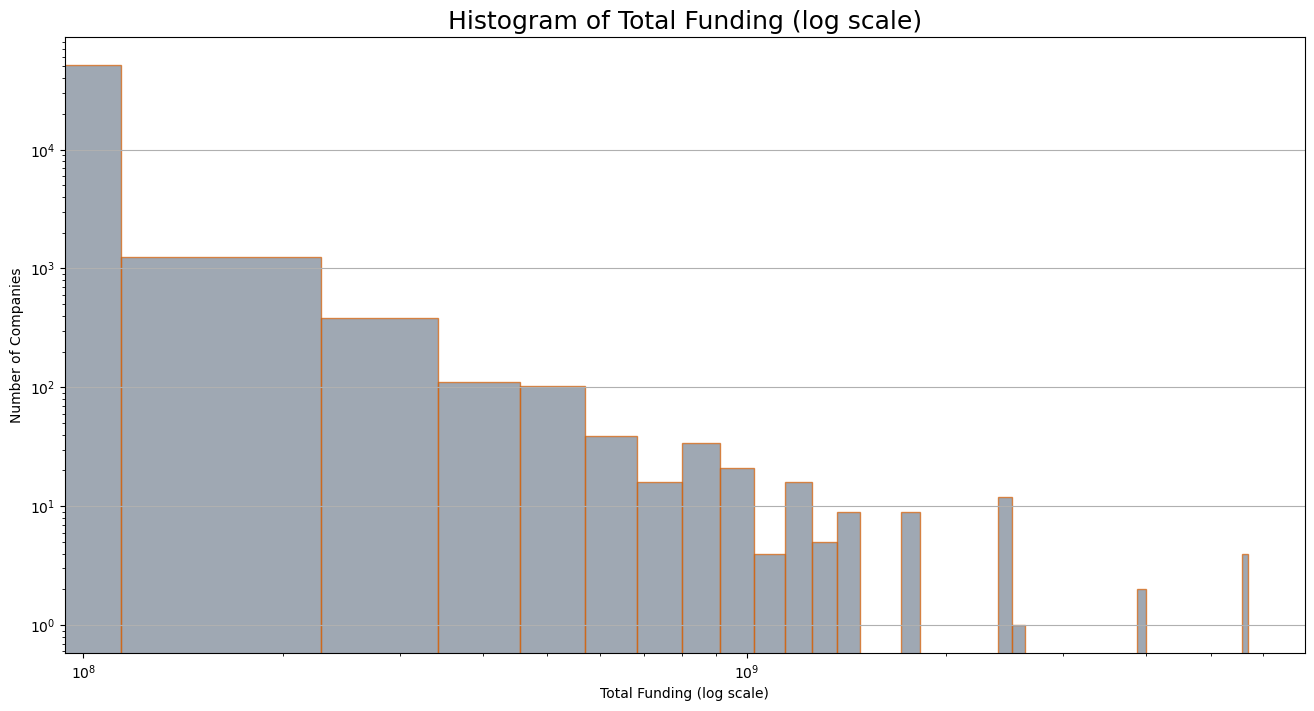

In [81]:
plt.figure(figsize=(16, 8))

# Build a histogram based on the column - funding_total
plt.hist(company_data_sort['funding_total'] ,
         bins=50,
         color='#768493',
         alpha=0.7,
         edgecolor='#d95f02')



# Apply a logarithmic scale
plt.xscale('log')
plt.yscale('log') 

# Add labels to the plot
plt.title('Histogram of Total Funding (log scale)', fontsize=18)
plt.xlabel('Total Funding (log scale)')
plt.ylabel('Number of Companies')

# Display grid lines
plt.grid(axis='y')

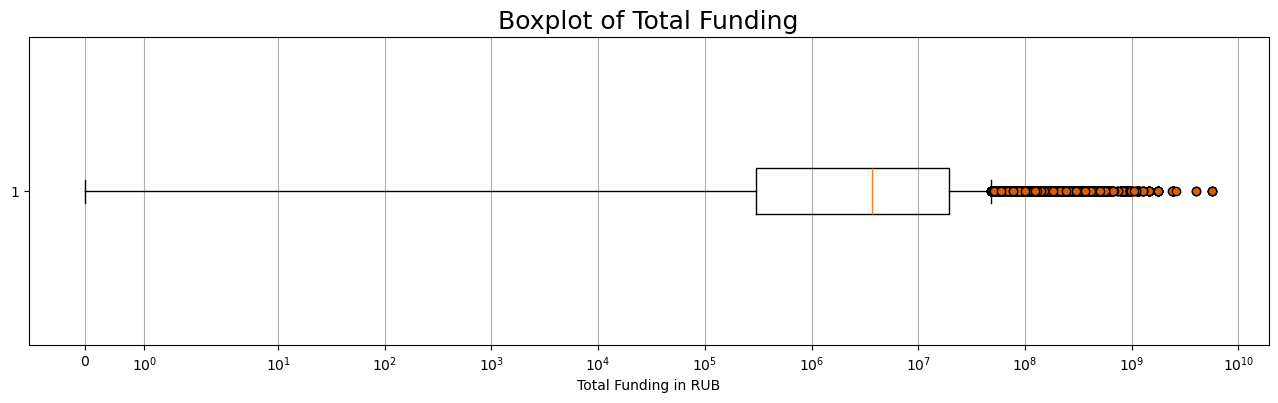

In [82]:
plt.figure(figsize=(16, 4))

plt.boxplot(company_data_sort['funding_total'],
            vert=False,
            flierprops=dict(markerfacecolor='#d95f02', marker='o'))

plt.xscale('symlog')
# Add plot labels
plt.title('Boxplot of Total Funding', fontsize=18)
plt.xlabel('Total Funding in RUB')

# Display grid lines
plt.grid(axis='x')

On the boxplot, we can see that our values start from 0 — these are likely companies that did not require funding. The 25th percentile begins at values above 100,000 RUB. The median is already at more than 1,000,000 RUB. A large number of outliers begin after 10,000,000 RUB. The largest outlier reaches over 1,000,000,000 RUB.

Let’s look at these values in detail using the `.describe()` method:

In [84]:
company_data_sort['funding_total'].describe()

count    5.331100e+04
mean     2.384544e+07
std      9.610376e+07
min      0.000000e+00
25%      3.000000e+05
50%      3.675790e+06
75%      1.960000e+07
max      5.700000e+09
Name: funding_total, dtype: float64

- The mean is 23.85 million RUB , which is significantly higher than the median (3.68 million RUB ) — this indicates the presence of outliers
- The minimum value is 0 , which is normal — it could represent companies that didn’t require funding
- The maximum value is 5.7 billion RUB , confirming the presence of very large deals

---
### 3.3 Purchased for free?

- We investigate companies that were sold for zero or one dollar, while having a known non-zero total funding amount.
  
- We will analytically calculate the upper and lower outlier boundaries for the `funding_total` column and specify which percentiles these boundaries correspond to.

In [88]:
# Look at the number of companies sold for 0 RUB
zero_price = (acquisition_df['price_amount'] == 0).sum()
print(f'Number of companies sold for zero: {zero_price}')

# Look at the number of companies sold for more than 0 RUB
not_zero_price = (acquisition_df['price_amount'] > 0).sum()
print(f'Number of companies sold for more than zero: {not_zero_price}')

Number of companies sold for zero: 6931
Number of companies sold for more than zero: 2476


In [89]:
# Combine dataframes into one for analysis
acquisition_company = pd.merge(acquisition_df, company_data_sort,
                              left_on='acquired_company_id', 
                              right_on='company_id_1')

# Check the connection
acquisition_company.head(2)

,id,acquiring_company_id,acquired_company_id,term_code,price_amount,acquired_at,company_id_1,name,category_code,founded_at,closed_at,domain,network_username,country_code,investment_rounds,funding_rounds,funding_total,status,milestones
0,1,11,10,NaN,20000000,2007-05-30,10,Flektor,games_video,NaT,NaT,flektor.com,unknown,USA,0.0,0.0,0.0,acquired,0.0
1,7,59,72,cash,60000000,2007-07-01,72,GrandCentral,mobile,2006-04-01,NaT,grandcentral.com,unknown,USA,0.0,1.0,4000000.0,acquired,4.0


In [90]:
sold_with_funding = acquisition_company[acquisition_company['funding_total'] > 0]
# Display the number of companies with funding
print(f"Number of companies sold with funding: {len(sold_with_funding)}")

print()
# Look at which field the companies operated in
print(sold_with_funding.groupby('category_code')['funding_total'].count().sort_values(ascending=False).head(10))


Number of companies sold with funding: 4365

category_code
software           784
web                535
mobile             396
enterprise         386
biotech            303
advertising        264
games_video        237
network_hosting    168
cleantech          135
semiconductor      126
Name: funding_total, dtype: int64


The total number of companies sold with funding was 4365, of which 784 companies worked in the software field. 535 companies in the web development field and 396 companies worked in the mobile development field.

Now let's look at the mean and median funding values for all companies and build a boxplot to see the data distribution:

In [92]:
# Look at the mean and median funding size
avg_funding = sold_with_funding['funding_total'].mean()
median_funding = sold_with_funding['funding_total'].median()
print(f'Mean funding: {round(avg_funding, 2)}\nMedian funding: {round(median_funding, 2)}')

Mean funding: 35906549.49
Median funding: 14400000.0


The Mean and Median funding values differ by a factor of two. This indicates the presence of significant outliers that make the mean higher than the median. Let's build a boxplot to visually see the number of outliers:

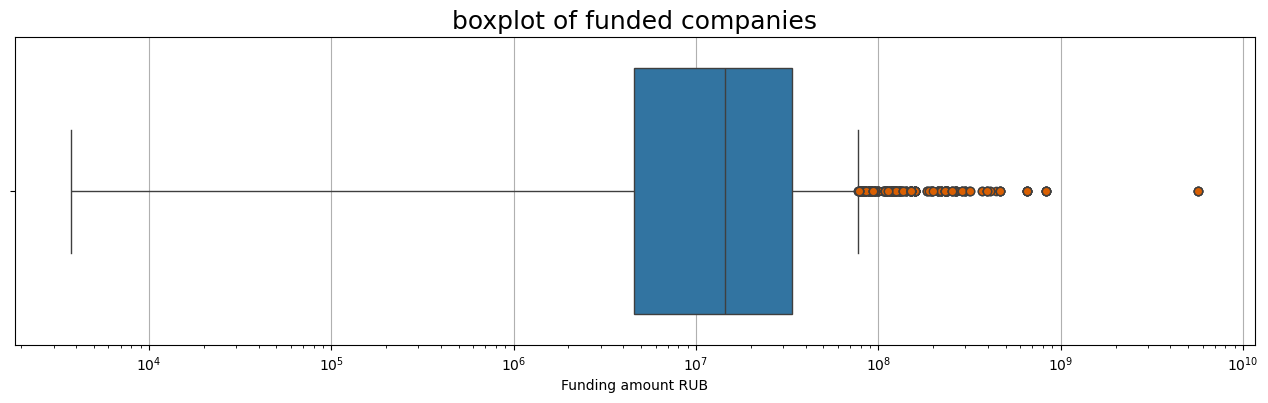

In [94]:
plt.figure(figsize=(16, 4))

# Build a boxplot
sns.boxplot(data=sold_with_funding, x='funding_total', 
            flierprops=dict(markerfacecolor='#d95f02', marker='o'))


plt.xscale('log')
plt.title('boxplot of funded companies', fontsize=18)
plt.xlabel('Funding amount RUB')
plt.grid(axis='x')

The majority of funding values fall between 10,000 RUB and over 10,000,000 RUB.

There are quite many points beyond the whiskers. These are outliers starting from values above 15,000,000 RUB that cause the mean to be higher than the median. The largest one is at the 100,000,000 RUB level.

- The 25th percentile on the graph is around over 1,000,000 RUB
- The 75th percentile on the graph is around over 10,000,000 RUB

Let's find the exact values of the 25th and 75th percentiles:

In [96]:
# Percentile calculation
Q1 = sold_with_funding['funding_total'].quantile(0.25)
Q3 = sold_with_funding['funding_total'].quantile(0.75)

print(f"Q1 (25th percentile): {round(Q1, 2)}")
print(f"Q3 (75th percentile): {round(Q3, 2)}")
print()

# Find the range
IQR = Q3 - Q1

print(f'Interquartile range (IQR): {round(IQR, 2)}')

Q1 (25th percentile): 4600000.0
Q3 (75th percentile): 33672700.0

Interquartile range (IQR): 29072700.0


---
### 3.4 3.4. Startup Prices by Category

Categories of startups with the highest valuations and significant valuation variance, which may be the most attractive for large investors who are willing to take high risks for potentially high returns. Among the categories of startups, identify the categories of startups characterized by:
- the highest typical valuations;
- and the greatest valuation variance per startup.

In [99]:
# Display typical prices by category
price_per_category = acquisition_company.groupby('category_code')['price_amount'].median().sort_values(ascending=False).head(10)
print(price_per_category)

category_code
nanotech         584000000.0
finance           56400000.0
manufacturing     56000000.0
real_estate       40000000.0
photo_video       40000000.0
biotech           26300000.0
hospitality       10000000.0
local              8070100.0
news                     0.0
nonprofit                0.0
Name: price_amount, dtype: float64


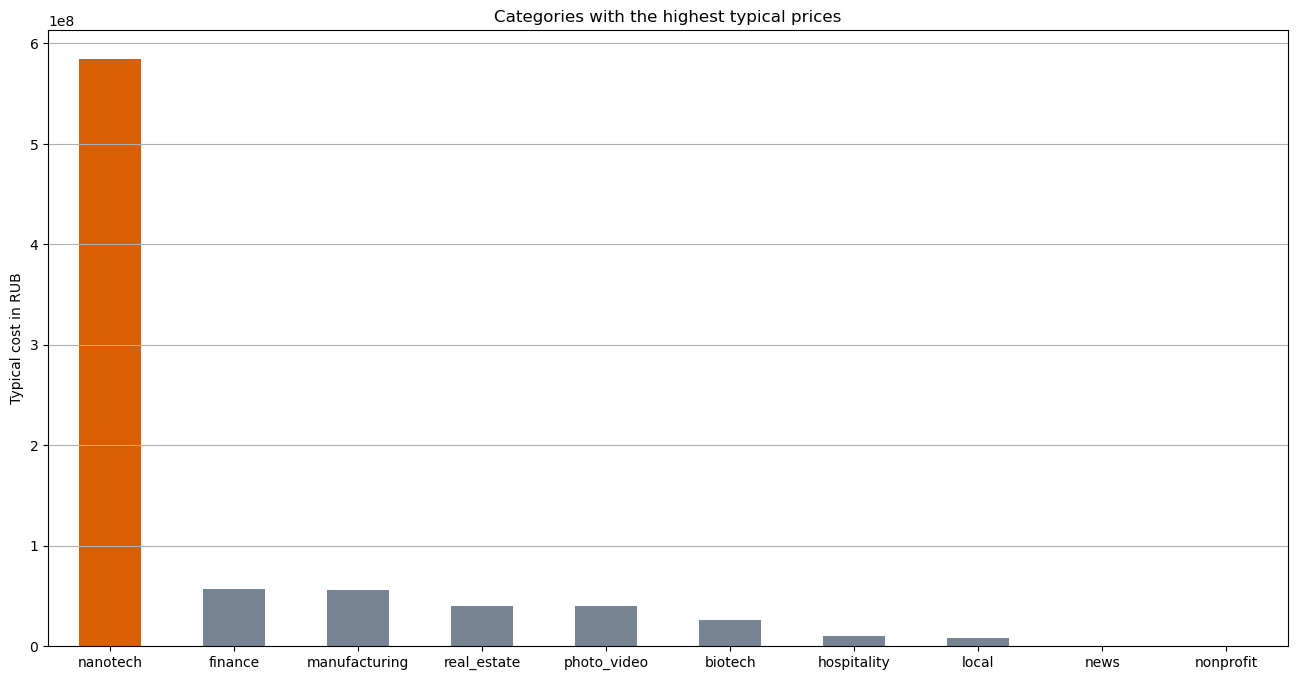

In [100]:
highlight_colour = '#d95f02'
non_highlight_colour = '#768493'
# Color-code the columns for 'cafe' and 'bakery'
colors = [highlight_colour if category_code == 'nanotech' else non_highlight_colour for category_code in price_per_category.index]


plt.figure(figsize=(16, 8))

ax = price_per_category.plot(kind='bar',
                             color=colors,
                             rot=0,
                             legend=False,
                             title='Categories with the highest typical prices',
                             xlabel='',
                             ylabel='Typical cost in RUB'
)

plt.grid(axis='y')

We compiled a top 10 list of companies with the highest typical prices.

The highest value of 584 million RUB is in the `nanotech` field. However, it’s worth checking how many companies were sold in this field—a small number could distort the conclusion.

Companies in the `finance` field had a typical price of 56.4 million RUB, lower than `nanotech` but still among the highest values compared to other fields.

Categories like `news`, `nonprofit`, and others show zero values, indicating either no significant sales or that these fields were sold for 0 RUB.

Now let’s check how many companies in the `nanotech` field had transaction data and complete information about them:

In [102]:
nanotech_comp = acquisition_company[acquisition_company['category_code'] == 'nanotech']
display(nanotech_comp)

,id,acquiring_company_id,acquired_company_id,term_code,price_amount,acquired_at,company_id_1,name,category_code,founded_at,closed_at,domain,network_username,country_code,investment_rounds,funding_rounds,funding_total,status,milestones
7480,9717,267726,221032,NaN,584000000,2013-09-26,221032,Zoltek Corporation,nanotech,NaT,NaT,zoltek.com,unknown,USA,0.0,0.0,0.0,acquired,1.0


In the end, we have only one company in the `nanotech` category that was acquired in 2013.

Now let's take a look at the startups with the highest price range:

In [104]:
std_per_category = acquisition_company.groupby('category_code')['price_amount'].std().sort_values(ascending=False).head(10)
print(std_per_category)

category_code
enterprise          1.102605e+11
public_relations    4.264719e+09
automotive          2.320778e+09
real_estate         2.129788e+09
biotech             1.415268e+09
other               1.208042e+09
health              1.009700e+09
manufacturing       9.585445e+08
software            7.567546e+08
finance             7.559660e+08
Name: price_amount, dtype: float64


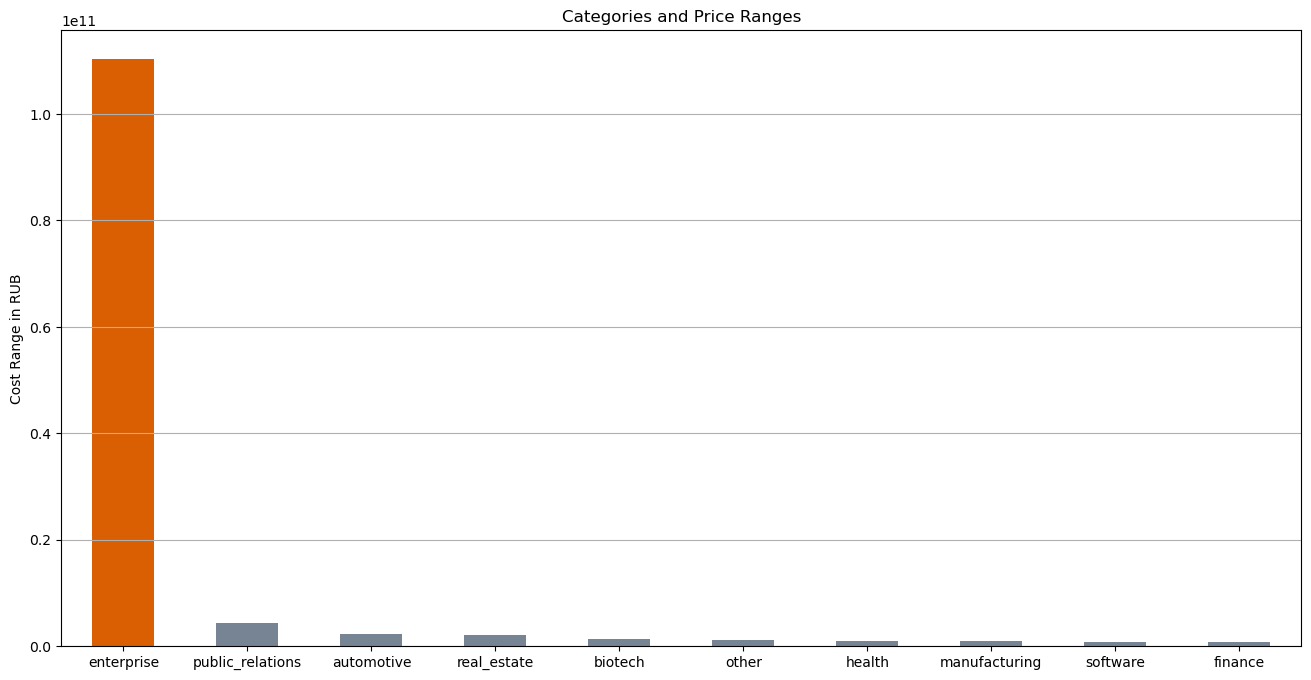

In [105]:
highlight_colour = '#d95f02'
non_highlight_colour = '#768493'
# Highlight columns for cafe and bakery with colors
colors = [highlight_colour if category_code == 'enterprise' else non_highlight_colour for category_code in std_per_category.index]


plt.figure(figsize=(16, 8))

ax = std_per_category.plot(kind='bar',
                             color=colors,
                             rot=0,
                             legend=False,
                             title='Categories and Price Ranges',
                             xlabel='',
                             ylabel='Cost Range in RUB'
)

plt.grid(axis='y')

The category with the highest price range is `enterprise` (with a standard deviation of approximately 110.26 billion RUB ), which suggests the presence of both extremely expensive and budget deals.

Categories with a high price range are attractive to large investors who are willing to take on risk in exchange for potentially higher returns. However, let's also look at other categories without `enterprise`, as it distorts the scale of the graph.

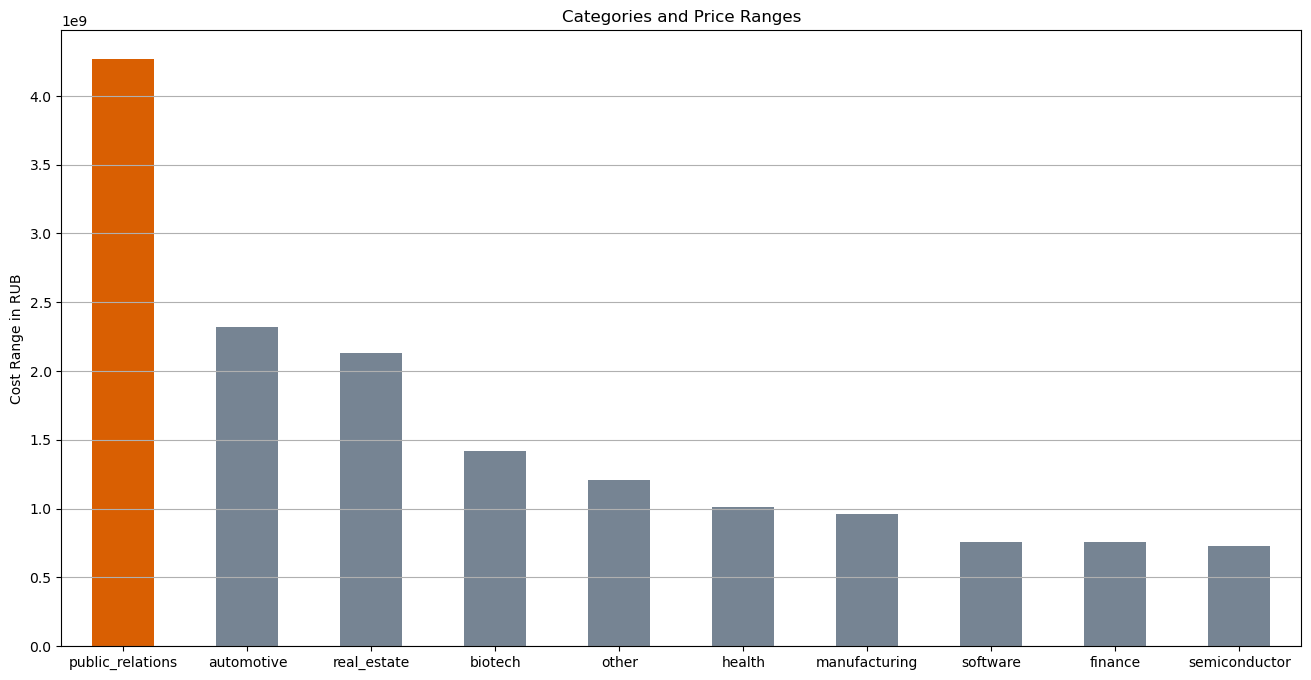

In [107]:
not_enterprise = acquisition_company[acquisition_company['category_code'] != 'enterprise']

std_per_category_2 = not_enterprise.groupby('category_code')['price_amount'].std().sort_values(ascending=False).head(10)

highlight_colour = '#d95f02'
non_highlight_colour = '#768493'
# Highlight columns for cafe and bakery with colors
colors = [highlight_colour if category_code == 'public_relations' else non_highlight_colour for category_code in std_per_category_2.index]


plt.figure(figsize=(16, 8))

ax = std_per_category_2.plot(kind='bar',
                             color=colors,
                             rot=0,
                             legend=False,
                             title='Categories and Price Ranges',
                             xlabel='',
                             ylabel='Cost Range in RUB'
)

plt.grid(axis='y')

In this visualization, we can see that companies in the field of `public_relations` are leading, with a standard deviation of approximately 4.26 billion RUB.

Why was the top-10 used in all conclusions and visualizations? Because it helps identify the key leading categories, and expanding the list would complicate our analysis rather than improve it.

---
### 3.5 How Many Funding Rounds Does a Startup Go Through Before Being Acquired

- It is necessary to analyze the `funding_rounds` column. Examine the values in this column. The client is interested in the typical number of funding rounds for each possible startup status.
- Build a graph that shows the average number of funding rounds startups from each group went through. Draw conclusions.

In [112]:
# Explore the typical number of funding rounds by status
rounds_per_status = company_data_sort.groupby('status')['funding_rounds'].median().sort_values(ascending=False).reset_index()
display(rounds_per_status)

,status,funding_rounds
0,ipo,3.0
1,operating,2.0
2,acquired,1.0
3,closed,1.0


The highest typical number of rounds — 3 on average — is found among companies with the `ipo` status (initial public offering).

The lowest typical number of rounds is observed for companies with the `closed` status, with an average of just 1 round.

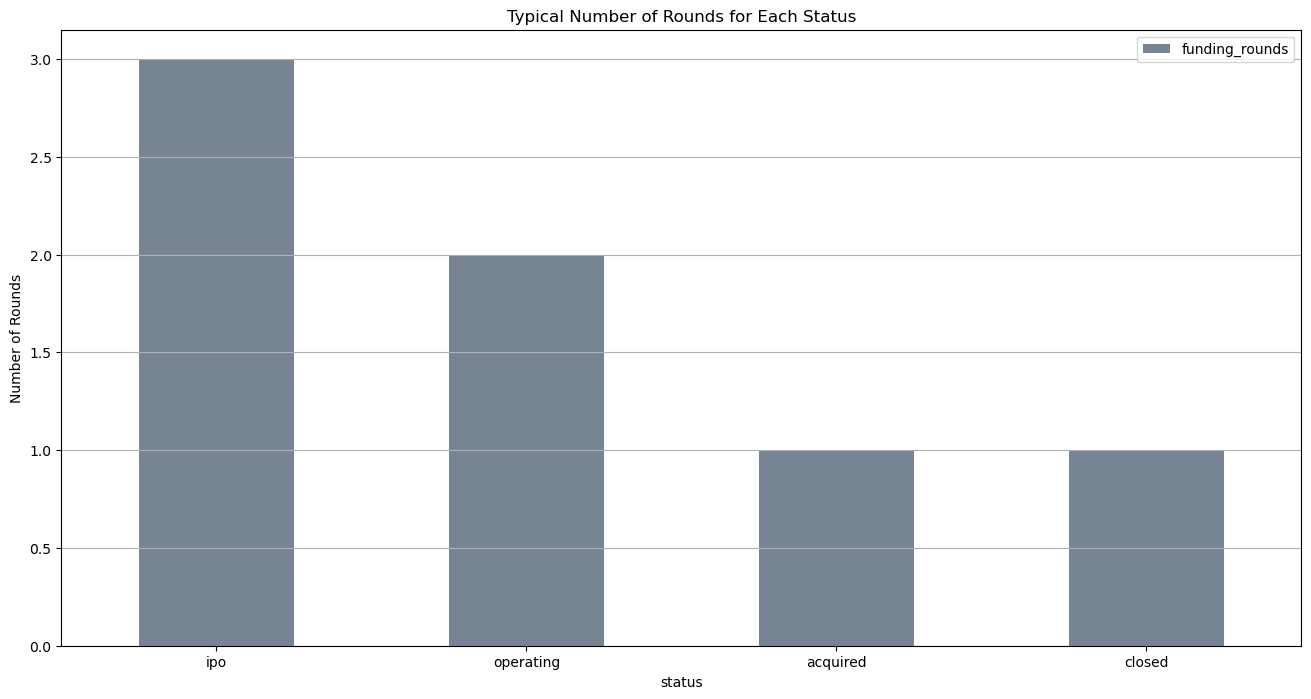

In [114]:
# Build a bar chart
rounds_per_status.plot(kind='bar',
                      x='status',
                      rot=0,
                      figsize=(16, 8),
                      color='#768493',
                      title='Typical Number of Rounds for Each Status',
                      ylabel='Number of Rounds')

plt.grid(axis='y')

The graph shows that companies with the status `ipo` lead in terms of the typical number of funding rounds.

Next is the status `operating`, with a typical value of 2 funding rounds.

The statuses `acquired` and `closed` have an average of just 1 funding round each.

Now let's take a look at the anomalous, minimum, and outlier values for each status:

In [116]:
# Let's examine anomalous and small values in each status
company_data_sort.groupby('status')['funding_rounds'].agg(['median', 'mean', 'min', 'max', 'std']).reset_index()

,status,median,mean,min,max,std
0,acquired,1.0,1.565265,0.0,12.0,1.942424
1,closed,1.0,1.967627,0.0,8.0,1.394152
2,ipo,3.0,4.033724,0.0,13.0,3.311915
3,operating,2.0,2.534499,0.0,15.0,1.913797


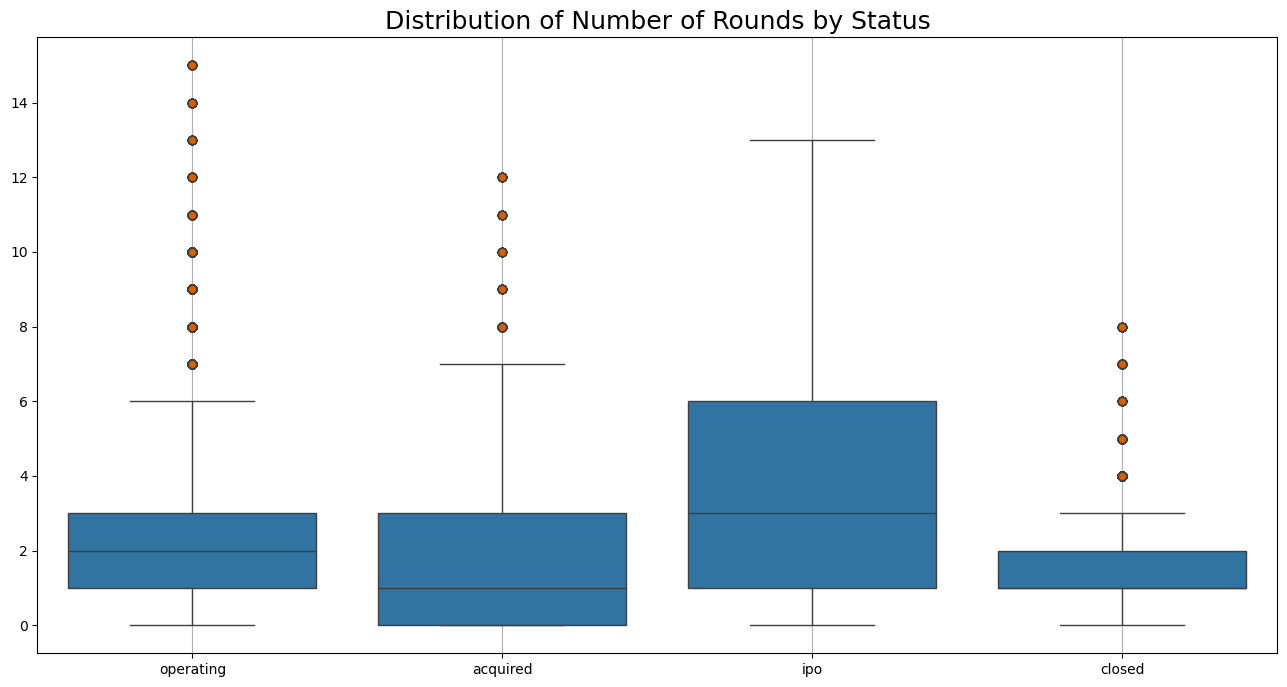

In [117]:
plt.figure(figsize=(16, 8))

# Build a boxplot
sns.boxplot(data=company_data_sort, x='status', y='funding_rounds',
           flierprops=dict(markerfacecolor='#d95f02', marker='o'))


plt.title('Distribution of Number of Rounds by Status', fontsize=18)
plt.xlabel('')
plt.ylabel('')
plt.grid(axis='x')

Companies with the status `ipo` have the widest range of funding rounds, which indicates multiple financings before going public.

Companies with the statuses `acquired` and `closed` have the fewest number of rounds, usually no more than 1–2.

## 4. Final Conclusion and Recommendations

### 4.1 General Overview of the Work Done

The data was loaded.

In this project, the following files were loaded:
`acquisition.csv`,
`company_and_rounds.csv`,
`education.csv`,
`people.csv`,
`degrees.csv`.

The following steps were performed:

- Reviewed the structure and content of all dataframes
- Conducted data preprocessing — corrected data types, analyzed missing values, and checked for both explicit and implicit duplicates
- Finally, split the `company_and_rounds.csv` dataframe into two parts and extracted only the necessary columns for analysis
- The most substantial part of the work was the Exploratory Data Analysis , where we examined various relationships in the data

### 4.2 Recommendations Based on Data Analysis

Focus on companies from the following categories, which dominate among the 4365 funded companies:

- Software (784 companies)
- Web (535 companies)
- Mobile (396 companies)
 High average funding amounts are observed in the categories
`nanotech`, `finance`, and `enterprise`.

However, the category `nanotech` had only one entry in the dataset, so there is a risk that replicating such success may not be realistic.

The majority of funding values fall within the range of 1 million to 33 million RUB .

The status `ipo` leads in terms of number of funding rounds (on average 3 rounds), indicating high investor interest and strong preparation of these companies for entering the market.